# CIFAR-10 CNN Training V3 (Full Dataset)
- Loads from `cifar10_v3_preprocessed.npz`
- 75K images (50K + 25K augmented)
- Denoised + CLAHE + Sharpened + Augmented + Cutout
- 50 Epochs with LR Scheduler

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import time

## 1. Setup Device

In [14]:
device = torch.device('mps' if torch.backends.mps.is_available() else 
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 2. Load Preprocessed Data

In [15]:
data = np.load('cifar10_v3_preprocessed.npz')

X_train = data['X_train'].astype(np.float32)
X_val = data['X_val'].astype(np.float32)
X_test = data['X_test'].astype(np.float32)
y_train = data['y_train'].astype(np.int64)
y_val = data['y_val'].astype(np.int64)
y_test = data['y_test'].astype(np.int64)
label_names = list(data['label_names'])

# Convert (N, H, W, C) -> (N, C, H, W) for PyTorch
X_train = X_train.transpose(0, 3, 1, 2)
X_val = X_val.transpose(0, 3, 1, 2)
X_test = X_test.transpose(0, 3, 1, 2)

print(f'Train: {X_train.shape} | Labels: {y_train.shape}')
print(f'Val:   {X_val.shape} | Labels: {y_val.shape}')
print(f'Test:  {X_test.shape} | Labels: {y_test.shape}')
print(f'Classes: {label_names}')

Train: (67500, 3, 32, 32) | Labels: (67500,)
Val:   (7500, 3, 32, 32) | Labels: (7500,)
Test:  (10000, 3, 32, 32) | Labels: (10000,)
Classes: [np.str_('airplane'), np.str_('automobile'), np.str_('bird'), np.str_('cat'), np.str_('deer'), np.str_('dog'), np.str_('frog'), np.str_('horse'), np.str_('ship'), np.str_('truck')]


## 3. Create DataLoaders

In [16]:
BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=256
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=256
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 528
Val batches:   30
Test batches:  40


## 4. Define CNN Model

In [17]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.4),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.5),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total Parameters: {total_params:,}')
print(model)

Total Parameters: 3,251,018
CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, p

## 5. Loss, Optimizer & Scheduler

In [18]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

print('Loss: CrossEntropyLoss (label_smoothing=0.1)')
print('Optimizer: SGD (lr=0.01, momentum=0.9, weight_decay=5e-4)')
print('Scheduler: CosineAnnealingLR (T_max=50)')

Loss: CrossEntropyLoss (label_smoothing=0.1)
Optimizer: SGD (lr=0.01, momentum=0.9, weight_decay=5e-4)
Scheduler: CosineAnnealingLR (T_max=50)


## 6. Training Loop (50 Epochs)

In [19]:
EPOCHS = 50
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

print(f'Training for {EPOCHS} epochs on {len(X_train):,} images (32x32)...')
print(f'{"="*65}')

start = time.time()

for epoch in range(EPOCHS):
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validate ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += criterion(out, yb).item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    val_loss /= val_total
    val_acc = val_correct / val_total

    # CosineAnnealing steps per epoch
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_v3.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | '
              f'LR: {current_lr:.6f} | Best: {best_val_acc*100:.2f}%')

elapsed = time.time() - start
print(f'{"="*65}')
print(f'Training completed in {elapsed:.1f}s')
print(f'Best Validation Accuracy: {best_val_acc*100:.2f}%')

Training for 50 epochs on 67,500 images (32x32)...
Epoch  1/50 | Train Loss: 1.6394 Acc: 47.67% | Val Loss: 1.3779 Acc: 60.72% | LR: 0.010000 | Best: 60.72%
Epoch  5/50 | Train Loss: 1.1283 Acc: 73.26% | Val Loss: 1.1471 Acc: 72.20% | LR: 0.009843 | Best: 72.96%
Epoch 10/50 | Train Loss: 0.9853 Acc: 80.21% | Val Loss: 1.0013 Acc: 78.79% | LR: 0.009222 | Best: 78.79%
Epoch 15/50 | Train Loss: 0.8994 Acc: 84.26% | Val Loss: 0.9508 Acc: 81.28% | LR: 0.008187 | Best: 83.05%
Epoch 20/50 | Train Loss: 0.8354 Acc: 87.29% | Val Loss: 0.8603 Acc: 85.31% | LR: 0.006841 | Best: 85.31%
Epoch 25/50 | Train Loss: 0.7830 Acc: 89.78% | Val Loss: 0.8397 Acc: 86.36% | LR: 0.005314 | Best: 86.36%
Epoch 30/50 | Train Loss: 0.7379 Acc: 92.07% | Val Loss: 0.8179 Acc: 87.25% | LR: 0.003757 | Best: 87.25%
Epoch 35/50 | Train Loss: 0.7020 Acc: 93.76% | Val Loss: 0.8097 Acc: 87.64% | LR: 0.002321 | Best: 88.05%
Epoch 40/50 | Train Loss: 0.6769 Acc: 95.00% | Val Loss: 0.7919 Acc: 88.67% | LR: 0.001147 | Best: 88

## 7. Test Set Evaluation

In [20]:
model.load_state_dict(torch.load('best_model_v3.pth', weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_preds.append(model(xb).argmax(1).cpu().numpy())
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)
test_acc = (y_pred == y_true).mean()

print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'\nPer-Class Accuracy:')
print('-' * 30)
for i, name in enumerate(label_names):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        print(f'  {name:<12s}: {acc*100:.1f}%')

Test Accuracy: 88.38%

Per-Class Accuracy:
------------------------------
  airplane    : 88.8%
  automobile  : 93.8%
  bird        : 81.6%
  cat         : 68.6%
  deer        : 92.1%
  dog         : 83.2%
  frog        : 94.9%
  horse       : 92.2%
  ship        : 94.8%
  truck       : 93.8%


## 8. Classification Report

In [21]:
print(classification_report(y_true, y_pred, target_names=label_names))

              precision    recall  f1-score   support

    airplane       0.91      0.89      0.90      1000
  automobile       0.95      0.94      0.95      1000
        bird       0.85      0.82      0.83      1000
         cat       0.85      0.69      0.76      1000
        deer       0.82      0.92      0.87      1000
         dog       0.83      0.83      0.83      1000
        frog       0.85      0.95      0.90      1000
       horse       0.92      0.92      0.92      1000
        ship       0.93      0.95      0.94      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## 9. Training Curves

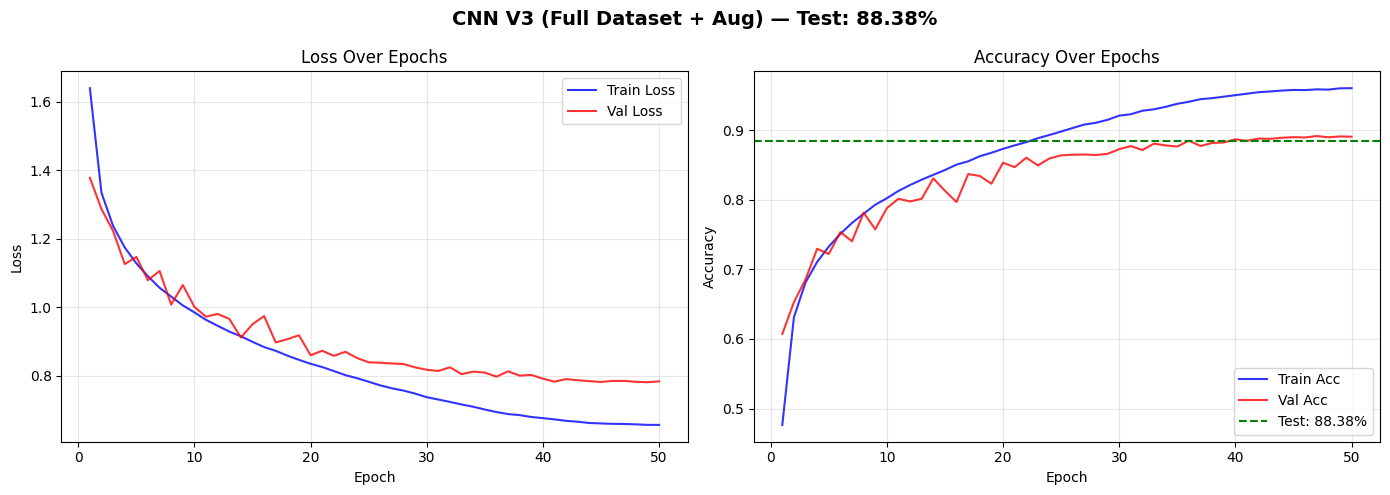

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', alpha=0.8)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', alpha=0.8)
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', alpha=0.8)
ax2.axhline(y=test_acc, color='green', linestyle='--', label=f'Test: {test_acc*100:.2f}%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'CNN V3 (Full Dataset + Aug) — Test: {test_acc*100:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=150)
plt.show()

## 10. Confusion Matrix

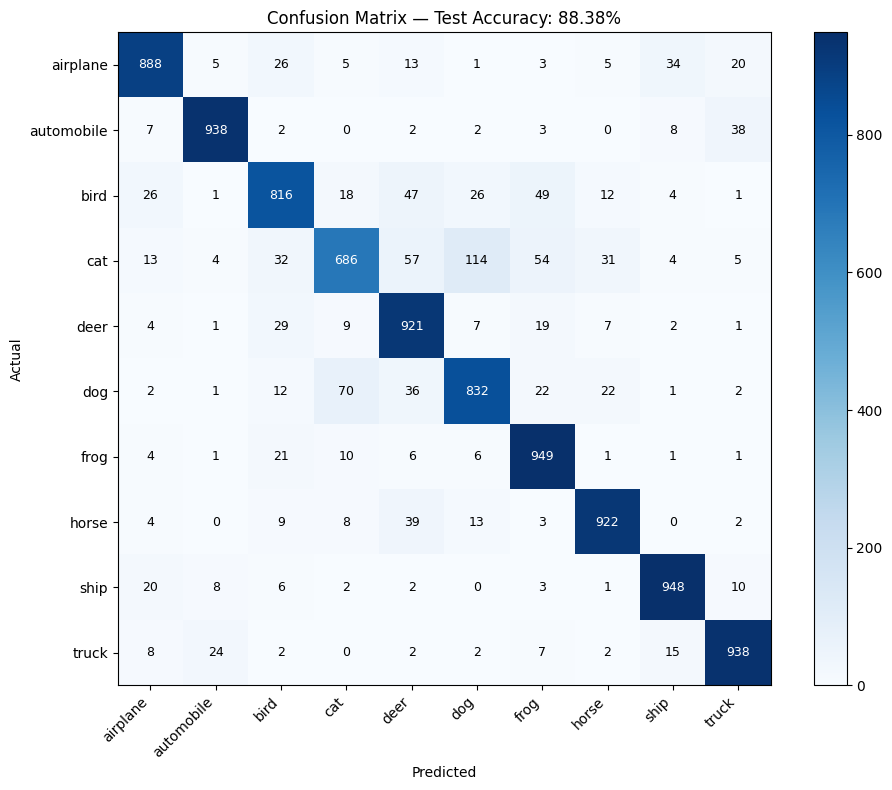

In [23]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%')

for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=color, fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150)
plt.show()

## 11. Sample Predictions

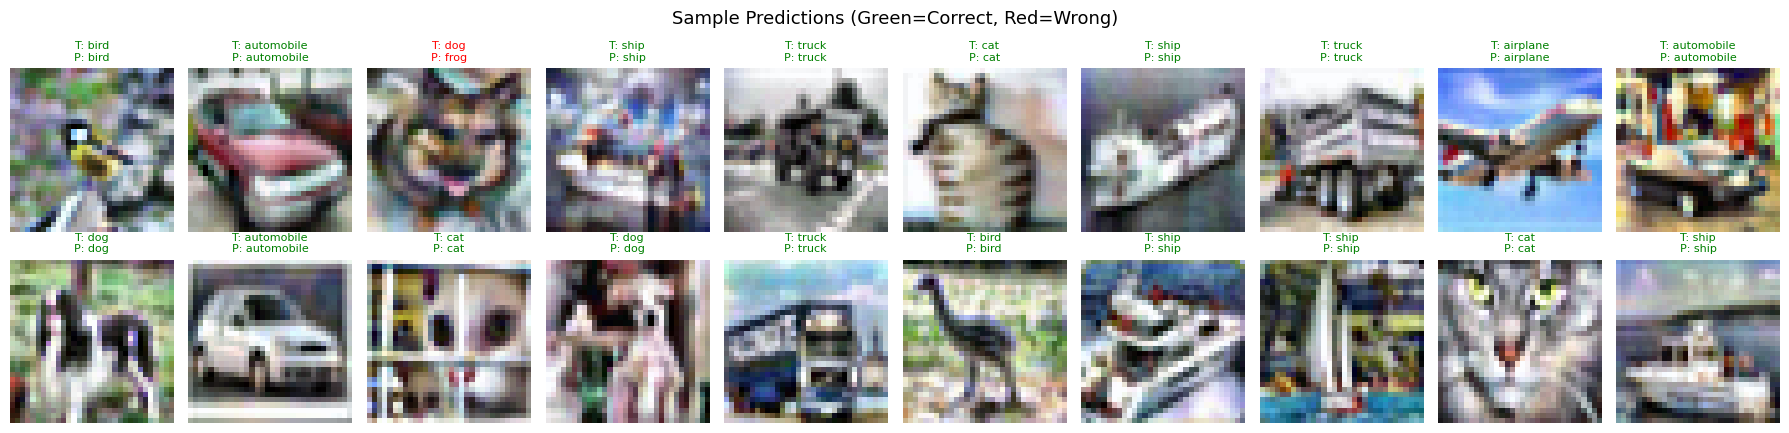

In [24]:
test_display = X_test.transpose(0, 2, 3, 1)
test_display = (test_display - test_display.min()) / (test_display.max() - test_display.min())

np.random.seed(42)
indices = np.random.choice(len(y_true), 20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4.5))
for i, idx in enumerate(indices):
    ax = axes[i // 10, i % 10]
    ax.imshow(test_display[idx])
    true_label = label_names[y_true[idx]]
    pred_label = label_names[y_pred[idx]]
    color = 'green' if y_true[idx] == y_pred[idx] else 'red'
    ax.set_title(f'T: {true_label}\nP: {pred_label}', fontsize=8, color=color)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions_v3.png', dpi=150)
plt.show()

## Summary

| Setting | Value |
|---|---|
| Data | `cifar10_v3_preprocessed.npz` |
| Total Images | 75K (50K + 25K augmented) |
| Preprocessing | Denoise + CLAHE + Sharpen |
| Augmentation | Flip + Rotation + Crop + Brightness + Cutout |
| Resolution | 32×32 (original) |
| Split | 67.5K train / 7.5K val / 10K test |
| Model | CNN (3 conv blocks) |
| Parameters | ~3.25M |
| Epochs | 50 |
| **Dropout** | **0.3 / 0.4 / 0.5 / 0.5** (increased) |
| **Loss** | **CrossEntropyLoss + Label Smoothing (0.1)** |
| **Optimizer** | **SGD (lr=0.01, momentum=0.9, weight_decay=5e-4)** |
| **Scheduler** | **CosineAnnealingLR (T_max=50)** |